In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.ar_model import AutoReg
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import grangercausalitytests
import warnings

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/dataset/Assignment 9 Data sheet.xlsx')

In [ ]:
df

,Year,Inflation,unemployment Rates,Repo Rate,Reverse Repo Rate
0,1960q1,5.133,0.908,3.933,3.745
1,1960q2,5.233,1.811,3.697,3.412
2,1960q3,5.533,1.623,2.937,2.698
3,1960q4,6.267,1.795,2.297,2.008
4,1961q1,6.800,0.537,2.003,1.998
...,...,...,...,...,...
159,1999q4,4.100,1.790,5.307,5.004
160,2000q1,4.033,3.669,5.680,5.348
161,2000q2,4.000,2.103,6.273,6.019
162,2000q3,4.067,1.868,6.520,6.178


In [ ]:
df.columns

Index(['Year', 'Inflation', 'unemployment Rates', 'Repo Rate',
       'Reverse Repo Rate'],
      dtype='object')

In [ ]:
df['Year'] = pd.to_datetime(df['Year']).dt.year
df_y = df.groupby('Year').mean()

In [ ]:
df_y

,Inflation,unemployment Rates,Repo Rate,Reverse Repo Rate
Year,,,,
1960,5.54150,1.53425,3.21600,2.96575
1961,6.69175,0.80300,1.95475,1.84475
1962,5.56650,1.45525,2.70850,2.58500
1963,5.64175,1.21875,3.17825,2.96000
1964,5.15850,1.58750,3.49675,3.24275
1965,4.50850,2.02300,4.07250,3.81850
1966,3.79175,3.36350,5.11075,4.85675
1967,3.84150,3.09775,4.21975,3.96575
1968,3.55825,4.54875,5.65675,5.40275


In [ ]:
df_y.columns

Index(['Inflation', 'unemployment Rates', 'Repo Rate', 'Reverse Repo Rate'], dtype='object')

In [ ]:
df_y.tail()

,Inflation,unemployment Rates,Repo Rate,Reverse Repo Rate
Year,,,,
1996,5.40825,1.84525,5.29825,5.04425
1997,4.94175,1.83150,5.46000,5.20600
1998,4.50800,1.13500,5.35325,5.09925
1999,4.22500,1.55075,4.97000,4.68100
2000,4.01675,2.34700,6.23650,5.92325


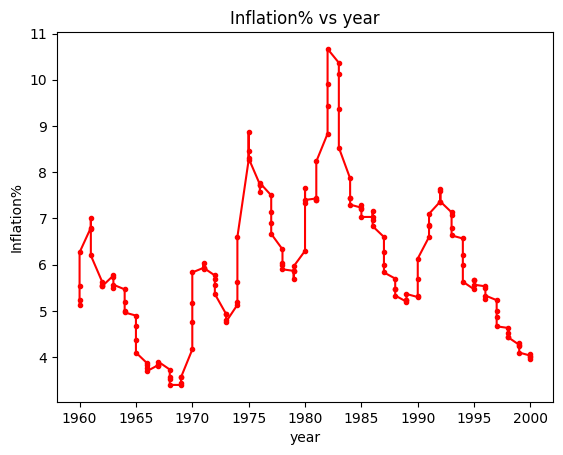

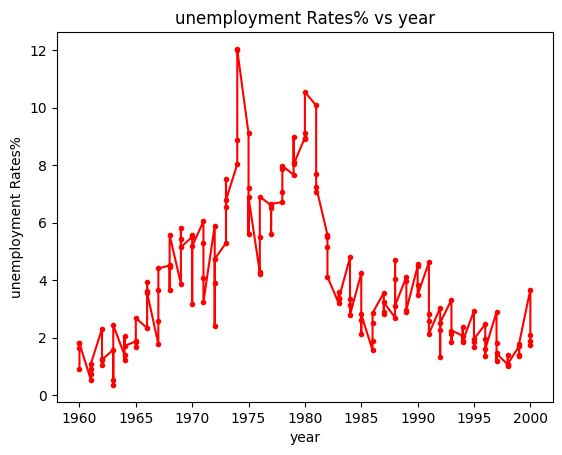

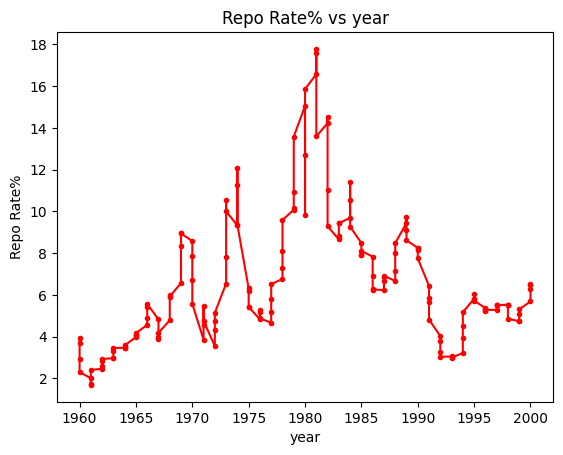

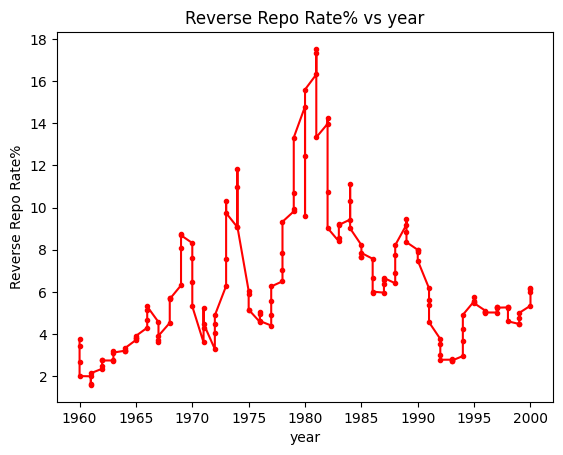

In [ ]:
for col in df.columns[1:]:
  plt.plot(df['Year'], df[col], marker='.', color='red')
  plt.title(f'{col}% vs year')
  plt.xlabel('year')
  plt.ylabel(f'{col}%')
  plt.show()

In [ ]:
inflation = df['Inflation']
unemployment_rate = df['unemployment Rates']
repo_rate = df['Repo Rate']
reverse_repo_rate = df['Reverse Repo Rate']

In [ ]:
def stationary(data):
  result = adfuller(data,autolag='AIC')
  print(f'optimum lag : {result[2]}')
  p = result[1]
  print(f'p-value : {p}')

  if p < 0.05:
      print("The variable is likely stationary.\n")
  else:
      print("The variable is likely non-stationary.\n")

print('Variable : Inflation')
stationary(inflation)

print('Variable : unemployment Rates')
stationary(unemployment_rate)

print('Variable : repo rate')
stationary(repo_rate)

print('Variable : reverse repo rate')
stationary(reverse_repo_rate)

Variable : Inflation
optimum lag : 1
p-value : 0.05498096723155771
The variable is likely non-stationary.

Variable : unemployment Rates
optimum lag : 2
p-value : 0.32655464342595064
The variable is likely non-stationary.

Variable : repo rate
optimum lag : 7
p-value : 0.1404061852494477
The variable is likely non-stationary.

Variable : reverse repo rate
optimum lag : 7
p-value : 0.13765071415976077
The variable is likely non-stationary.



In [ ]:
quarterly_periods = pd.date_range(start='2024-01-01', periods=20, freq='Q').to_period()


for column in ['unemployment Rates', 'Repo Rate', 'Reverse Repo Rate']:

    model = AutoReg(df['Inflation'], lags = 2)
    model_fit = model.fit()

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        # Granger Causality Test
        print(f"\nGranger Causality Test for {column} with Inflation:")
        granger_test_result = grangercausalitytests(df[['Inflation', column]], maxlag=7, verbose=False)
        for lag in granger_test_result.keys():
            print(f"  Lag {lag}: p-value = {granger_test_result[lag][0]['ssr_ftest'][1]}")


    print(f"\nModel summary for {column}:")
    print(model_fit.summary())
    forecast = model_fit.forecast(steps=20)
    forecast.index = quarterly_periods
    print(f"\nForecast for Inflation for the next 5 years (2024-2030) using {column}:\n{forecast}")


Granger Causality Test for unemployment Rates with Inflation:
  Lag 1: p-value = 6.281744785558605e-08
  Lag 2: p-value = 0.00016368980404629397
  Lag 3: p-value = 0.00044386338548888947
  Lag 4: p-value = 0.00031235584542798245
  Lag 5: p-value = 0.0004144419348647724
  Lag 6: p-value = 0.0009732386712970456
  Lag 7: p-value = 0.0015049203909040002

Model summary for unemployment Rates:
                            AutoReg Model Results                             
Dep. Variable:              Inflation   No. Observations:                  164
Model:                     AutoReg(2)   Log Likelihood                  -3.957
Method:               Conditional MLE   S.D. of innovations              0.248
Date:                Thu, 21 Mar 2024   AIC                             15.914
Time:                        11:23:31   BIC                             28.264
Sample:                             2   HQIC                            20.928
                                  164                  

In [ ]:
quarterly_periods = pd.date_range(start='2024-01-01', periods=24, freq='Q').to_period()


for column in ['unemployment Rates', 'Repo Rate', 'Reverse Repo Rate']:

    model = ARIMA(df['Inflation'], order=(1, 1, 1))
    model_fit = model.fit(cov_type='robust')

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        # Granger Causality Test
        print(f"\nGranger Causality Test for {column} with Inflation:")
        granger_test_result = grangercausalitytests(df[['Inflation', column]], maxlag=7, verbose=False)
        for lag in granger_test_result.keys():
            print(f"  Lag {lag}: p-value = {granger_test_result[lag][0]['ssr_ftest'][1]}")


    print(f"\nModel summary for {column}:")
    print(model_fit.summary())
    lag_length = len(model_fit.arparams)
    forecast = model_fit.forecast(steps=24)
    forecast.index = quarterly_periods
    print(f"\nLag length: {lag_length}")
    print(f"\nForecast for Inflation for the next 6 years (2024-2030) using {column}:\n{forecast}")


Granger Causality Test for unemployment Rates with Inflation:
  Lag 1: p-value = 6.281744785558605e-08
  Lag 2: p-value = 0.00016368980404629397
  Lag 3: p-value = 0.00044386338548888947
  Lag 4: p-value = 0.00031235584542798245
  Lag 5: p-value = 0.0004144419348647724
  Lag 6: p-value = 0.0009732386712970456
  Lag 7: p-value = 0.0015049203909040002

Model summary for unemployment Rates:
                               SARIMAX Results                                
Dep. Variable:              Inflation   No. Observations:                  164
Model:                 ARIMA(1, 1, 1)   Log Likelihood                  -6.780
Date:                Thu, 21 Mar 2024   AIC                             19.561
Time:                        11:15:14   BIC                             28.842
Sample:                             0   HQIC                            23.329
                                - 164                                         
Covariance Type:               robust                  